# Resolution Convergence Study\n\nAnalysis of FDTD simulation convergence for the GaAs disk resonator with tuner element.\nGeometry: r=3.5 µm, gap=20 nm, tuner gap=20 nm, tuner width=100 nm, n_eff=2.9933.\nResolutions: 8, 12, 16, 24, 32, 48, 64, 80 px/µm.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.signal import find_peaks
import os, glob

# Publication style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "mathtext.fontset": "cm",
})

COL_WIDTH = 3.4
DBL_WIDTH = 7.0
c0 = 299792458

# Qualitative colormap — distinct colors for each resolution
cmap_qual = plt.cm.get_cmap("plasma")

def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12

def res_color(res, resolutions):
    """Return a distinct color for each resolution value."""
    idx = list(resolutions).index(res)
    return cmap_qual(idx / max(len(resolutions) - 1, 1))

SAVE = True
DATA_DIR = "data/convergence_study"
fig_dir = os.path.join(DATA_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)

/tmp/ipykernel_1917146/261245998.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_qual = plt.cm.get_cmap("plasma")


In [105]:
# ============================================================
# Load all resolution data
# ============================================================
res_folders = sorted(glob.glob(os.path.join(DATA_DIR, "res_*")),
                     key=lambda x: int(os.path.basename(x).split("_")[1]))

resolutions = []
runtimes = []
spectra_bus = {}
spectra_disk = {}
freqs_dict = {}

for folder in res_folders:
    res = int(os.path.basename(folder).split("_")[1])
    resolutions.append(res)

    f = np.load(os.path.join(folder, "freqs_thz.npy"))
    bus = np.load(os.path.join(folder, "flux_bus.npy"))
    disk = np.load(os.path.join(folder, "flux_disk.npy"))
    norm = np.load(os.path.join(folder, "norm_flux.npy"))
    rt = float(open(os.path.join(folder, "runtime_seconds.txt")).read().strip())

    # Normalize
    n = np.where(np.abs(norm) > 1e-20, norm, 1e-20)
    spectra_bus[res] = bus / n
    spectra_disk[res] = np.abs(disk / n)
    freqs_dict[res] = f
    runtimes.append(rt)

resolutions = np.array(resolutions)
runtimes = np.array(runtimes)

print(f"Resolutions: {resolutions}")
print(f"Runtimes: {[f'{r:.0f}s' for r in runtimes]}")

# Also load CSV summary
import csv
csv_path = os.path.join(DATA_DIR, "convergence_summary.csv")
csv_data = {}
with open(csv_path) as f:
    reader = csv.DictReader(f)
    for row in reader:
        res = int(row["resolution"])
        peaks = []
        for i in range(1, 6):
            val = row.get(f"peak_{i}_thz", "")
            if val:
                peaks.append(float(val))
        csv_data[res] = peaks

print("\nResonance peaks from CSV:")
for res in sorted(csv_data.keys()):
    peaks_str = ", ".join(f"{p:.2f}" for p in csv_data[res])
    print(f"  res={res:>3}: [{peaks_str}]")

Resolutions: [ 16  24  32  48  64  80  96 128]
Runtimes: ['515s', '1581s', '2618s', '4921s', '8176s', '9787s', '15969s', '30164s']

Resonance peaks from CSV:
  res= 96: [310.87, 315.60, 318.59, 320.32, 325.03]
  res=128: [311.06, 315.79, 318.78, 320.51, 325.24]


## Spectra comparison across resolutions

/tmp/ipykernel_1917146/261245998.py:39: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1917146/261245998.py:39: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


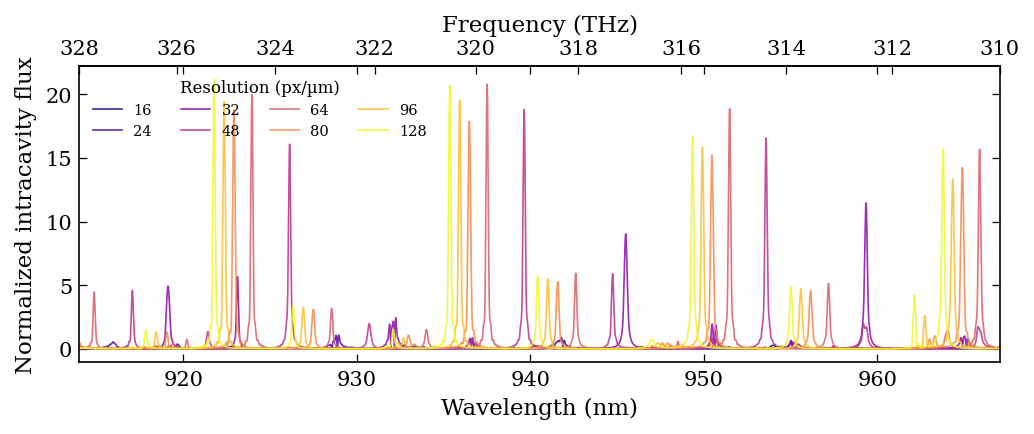

In [106]:
# ============================================================
# Plot 1: Overlay of disk flux spectra at all resolutions
# ============================================================
FREQ_MIN, FREQ_MAX = 310, 328
WL_MIN, WL_MAX = thz_to_nm(FREQ_MAX), thz_to_nm(FREQ_MIN)  # reversed (higher freq = shorter wl)

fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))

for res in resolutions:
    f = freqs_dict[res]
    mask = (f >= FREQ_MIN) & (f <= FREQ_MAX)
    wl = thz_to_nm(f[mask])
    color = res_color(res, resolutions)
    ax.plot(wl, spectra_disk[res][mask], color=color,
            linewidth=0.8, alpha=0.85, label=f"{res}")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized intracavity flux")
ax.set_xlim(WL_MIN, WL_MAX)

ax_top = ax.secondary_xaxis("top", functions=(nm_to_thz, thz_to_nm))
ax_top.set_xlabel("Frequency (THz)")

ax.legend(title="Resolution (px/µm)", fontsize=7, title_fontsize=8,
          ncol=4, loc="upper left")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_overlay.{ext}"))
plt.show()

/tmp/ipykernel_1917146/261245998.py:39: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1917146/261245998.py:39: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


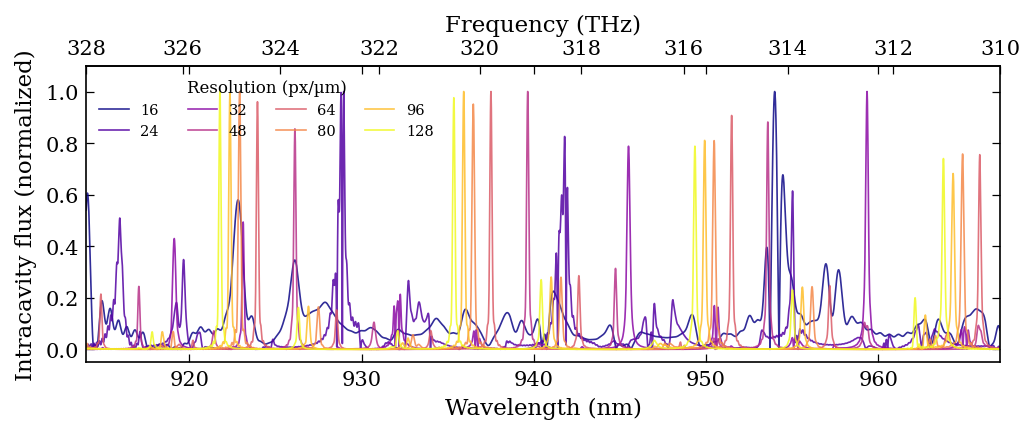

In [107]:
# ============================================================
# Plot 1b: Normalized spectra — each resolution scaled to [0,1]
# ============================================================
fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))

for res in resolutions:
    f = freqs_dict[res]
    mask = (f >= FREQ_MIN) & (f <= FREQ_MAX)
    wl = thz_to_nm(f[mask])
    spec = spectra_disk[res][mask].copy()
    smax = spec.max()
    if smax > 0:
        spec /= smax
    color = res_color(res, resolutions)
    ax.plot(wl, spec, color=color,
            linewidth=0.8, alpha=0.85, label=f"{res}")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Intracavity flux (normalized)")
ax.set_xlim(WL_MIN, WL_MAX)
ax.set_ylim(-0.05, 1.1)

ax_top = ax.secondary_xaxis("top", functions=(nm_to_thz, thz_to_nm))
ax_top.set_xlabel("Frequency (THz)")

ax.legend(title="Resolution (px/µm)", fontsize=7, title_fontsize=8,
          ncol=4, loc="upper left")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_overlay_normalized.{ext}"))
plt.show()

Reference peak at 325.24 THz / 921.77 nm (res=128)


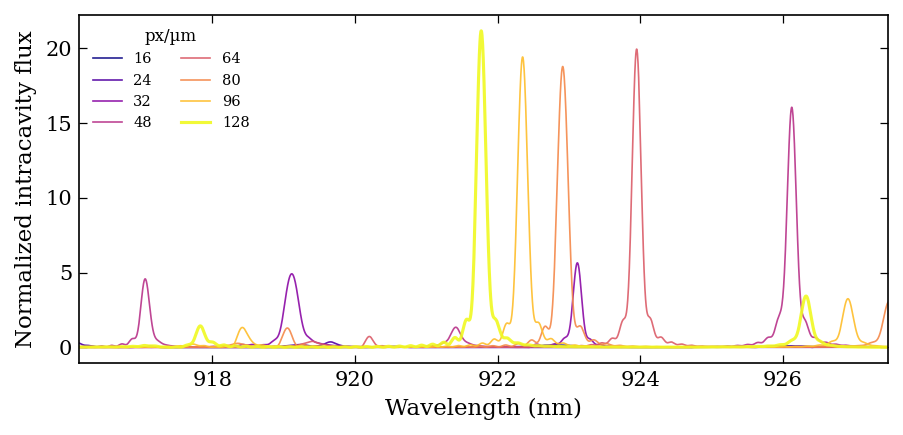

In [108]:
# ============================================================
# Plot 2: Zoomed comparison — highest res vs others around one peak
# ============================================================
ref_res = resolutions[-1]
f_ref = freqs_dict[ref_res]
spec_ref = spectra_disk[ref_res]
peaks_ref, props_ref = find_peaks(spec_ref, prominence=1.0,
                                   distance=int(0.5 / (f_ref[1] - f_ref[0])))
strongest = peaks_ref[np.argmax(props_ref["prominences"])]
f_peak = f_ref[strongest]
wl_peak = thz_to_nm(f_peak)
print(f"Reference peak at {f_peak:.2f} THz / {wl_peak:.2f} nm (res={ref_res})")

ZOOM_HALF = 2.0  # THz
wl_zoom_min = thz_to_nm(f_peak + ZOOM_HALF)
wl_zoom_max = thz_to_nm(f_peak - ZOOM_HALF)

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.8, 3.0))

for res in resolutions:
    f = freqs_dict[res]
    mask = (f >= f_peak - ZOOM_HALF) & (f <= f_peak + ZOOM_HALF)
    wl = thz_to_nm(f[mask])
    color = res_color(res, resolutions)
    lw = 1.5 if res == ref_res else 0.8
    ax.plot(wl, spectra_disk[res][mask], color=color,
            linewidth=lw, alpha=0.9, label=f"{res}")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized intracavity flux")
ax.set_xlim(wl_zoom_min, wl_zoom_max)
ax.legend(title="px/µm", fontsize=7, title_fontsize=8, ncol=2)

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_zoom_peak.{ext}"))
plt.show()

## Convergence of resonance frequency

In [109]:
# ============================================================
# Track the strongest resonance peak across all resolutions
# ============================================================
# Use the highest resolution (80) as ground truth, seed-and-track downward

SEARCH_WINDOW = 3.0  # THz — wider window for low-res tracking

# Seed: strongest peak at res=80
ref_res = resolutions[-1]
f_ref = freqs_dict[ref_res]
spec_ref = spectra_disk[ref_res]
peaks, props = find_peaks(spec_ref, prominence=1.0,
                          distance=int(0.5 / (f_ref[1] - f_ref[0])))
# Track top 3 peaks
top3_idx = np.argsort(props["prominences"])[::-1][:3]
seed_freqs = sorted(f_ref[peaks[top3_idx]])

print(f"Seed peaks at res={ref_res}: {[f'{f:.2f}' for f in seed_freqs]} THz")

# Track each peak across resolutions (from highest to lowest)
tracked = {k: [] for k in range(len(seed_freqs))}
tracked_res = []

for res in reversed(resolutions):
    f = freqs_dict[res]
    spec = spectra_disk[res]
    tracked_res.append(res)

    for k, seed_f in enumerate(seed_freqs):
        ref_f = seed_f if len(tracked[k]) == 0 else tracked[k][-1]
        mask = (f >= ref_f - SEARCH_WINDOW) & (f <= ref_f + SEARCH_WINDOW)
        local_peaks, local_props = find_peaks(spec[mask], prominence=0.3)

        if len(local_peaks) > 0:
            best = local_peaks[np.argmax(local_props["prominences"])]
            tracked[k].append(f[mask][best])
        else:
            tracked[k].append(np.nan)

tracked_res = np.array(tracked_res[::-1])  # low → high
for k in tracked:
    tracked[k] = np.array(tracked[k][::-1])

# Print convergence table
print(f"\n{'Res':>5} | ", end="")
for k in range(len(seed_freqs)):
    print(f"Peak {k+1} (THz)  ", end="")
print(f"| {'Runtime':>10}")
print("-" * 70)
for i, res in enumerate(tracked_res):
    rt_idx = np.where(resolutions == res)[0][0]
    print(f"{res:>5} | ", end="")
    for k in range(len(seed_freqs)):
        val = tracked[k][i]
        if np.isnan(val):
            print(f"{'---':>14}  ", end="")
        else:
            print(f"{val:>14.4f}  ", end="")
    print(f"| {runtimes[rt_idx]:>8.0f}s")

Seed peaks at res=128: ['315.79', '320.51', '325.24'] THz

  Res | Peak 1 (THz)  Peak 2 (THz)  Peak 3 (THz)  |    Runtime
----------------------------------------------------------------------
   16 |            ---             ---             ---  |      515s
   24 |       313.9093        318.3215        322.7187  |     1581s
   32 |       312.4942        317.0725        324.7608  |     2618s
   48 |       314.3823        319.0486        323.7068  |     4921s
   64 |       315.0774        319.7756        324.4688  |     8176s
   80 |       315.4134        320.1256        324.8328  |     9787s
   96 |       315.5964        320.3156        325.0309  |    15969s
  128 |       315.7854        320.5116        325.2359  |    30164s


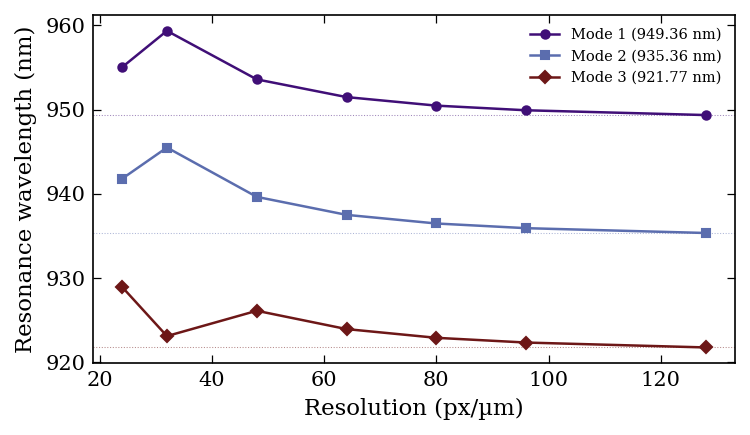

In [110]:
# ============================================================
# Plot 3a: Resonance wavelength vs resolution (absolute)
# ============================================================
ref_vals = {k: tracked[k][-1] for k in tracked}  # freq at highest res
ref_wl = {k: thz_to_nm(ref_vals[k]) for k in tracked}

colors_peak = ["#400F77", "#5B6DAE", "#6D1717"]
markers = ["o", "s", "D"]

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.5, 3.0))

for k in tracked:
    valid = ~np.isnan(tracked[k])
    wl = thz_to_nm(tracked[k][valid])
    ax.plot(tracked_res[valid], wl,
            f"{markers[k]}-", color=colors_peak[k],
            markersize=4, linewidth=1.2,
            label=f"Mode {k+1} ({ref_wl[k]:.2f} nm)")
    ax.axhline(ref_wl[k], color=colors_peak[k], ls=":", lw=0.5, alpha=0.5)

ax.set_xlabel("Resolution (px/µm)")
ax.set_ylabel("Resonance wavelength (nm)")
ax.legend(fontsize=7)

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"convergence_absolute.{ext}"))
plt.show()

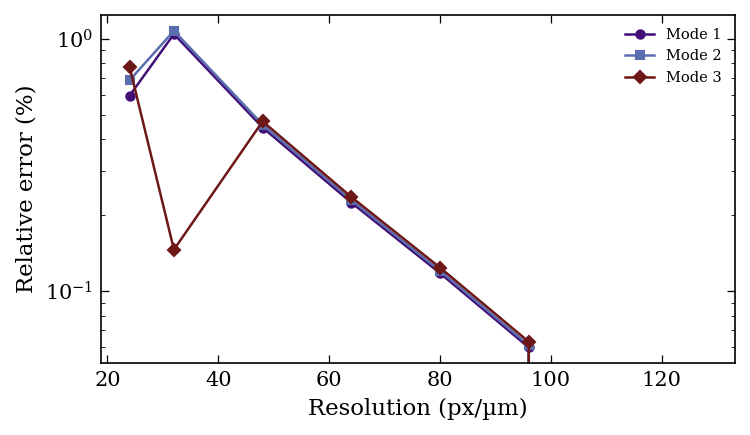

relative errors for each resolution (averaged)
  res= 16: nan%
  res= 24: 0.6838%
  res= 32: 0.7538%
  res= 48: 0.4570%
  res= 64: 0.2299%
  res= 80: 0.1207%
  res= 96: 0.0613%
  res=128: 0.0000%


In [115]:
# ============================================================
# Plot 3b: Relative error vs resolution
# ============================================================
# Shows |f_res - f_ref| / f_ref × 100% on a log scale.
# f_ref = frequency at the highest resolution (ground truth).
# As resolution increases, all modes should converge toward 0%.

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.5, 3.0))

for k in tracked:
    valid = ~np.isnan(tracked[k])
    rel_err = np.abs(tracked[k][valid] - ref_vals[k]) / ref_vals[k] * 100
    ax.plot(tracked_res[valid], rel_err,
            f"{markers[k]}-", color=colors_peak[k],
            markersize=4, linewidth=1.2,
            label=f"Mode {k+1}")

ax.set_xlabel("Resolution (px/µm)")
ax.set_ylabel("Relative error (%)")
ax.set_yscale("log")
ax.legend(fontsize=7)

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"convergence_relative_error.{ext}"))
plt.show()

print("relative errors for each resolution (averaged)")
for i, res in enumerate(tracked_res):
    errs = []
    for k in tracked:
        if not np.isnan(tracked[k][i]):
            err = np.abs(tracked[k][i] - ref_vals[k]) / ref_vals[k] * 100
            errs.append(err)
    avg_err = np.mean(errs) if len(errs) > 0 else np.nan
    print(f"  res={res:>3}: {avg_err:.4f}%")   



## Runtime scaling

Runtime ≈ 1.54e+00 × res^2.03
Expected for 2D FDTD: exponent ≈ 3 (grid² × timesteps)


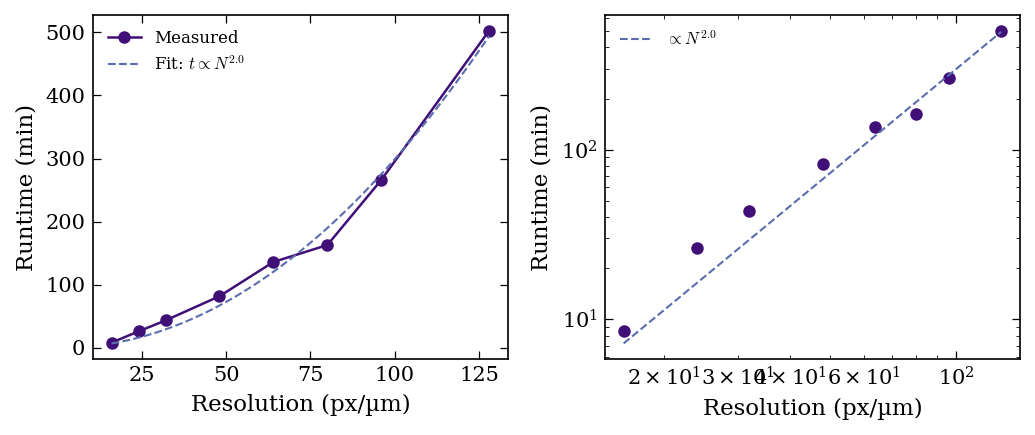


  Res |    Runtime |   Grid pts |  pts/λ
---------------------------------------------
   16 |      8.6 m |     33,300 |    4.9
   24 |     26.4 m |     74,926 |    7.3
   32 |     43.6 m |    133,201 |    9.8
   48 |     82.0 m |    299,704 |   14.7
   64 |    136.3 m |    532,807 |   19.5
   80 |    163.1 m |    832,512 |   24.4
   96 |    266.2 m |  1,198,817 |   29.3
  128 |    502.7 m |  2,131,230 |   39.1


In [112]:
# ============================================================
# Plot 4: Runtime vs resolution + power-law fit
# ============================================================
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * x**b

# Fit power law to runtime data (skip very low res that may not be reliable)
fit_mask = resolutions >= 16
popt, pcov = curve_fit(power_law, resolutions[fit_mask], runtimes[fit_mask])
a_fit, b_fit = popt
print(f"Runtime ≈ {a_fit:.2e} × res^{b_fit:.2f}")
print(f"Expected for 2D FDTD: exponent ≈ 3 (grid² × timesteps)")

res_fine = np.linspace(resolutions.min(), resolutions.max(), 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DBL_WIDTH, 3.0))

# Left: linear scale
ax1.plot(resolutions, runtimes / 60, "o-", color="#400F77",
         markersize=5, linewidth=1.2, label="Measured")
ax1.plot(res_fine, power_law(res_fine, *popt) / 60, "--",
         color="#5B6DAE", linewidth=1.0,
         label=f"Fit: $t \\propto N^{{{b_fit:.1f}}}$")
ax1.set_xlabel("Resolution (px/µm)")
ax1.set_ylabel("Runtime (min)")
ax1.legend(fontsize=8)

# Right: log-log scale
ax2.loglog(resolutions, runtimes / 60, "o", color="#400F77",
           markersize=5)
ax2.loglog(res_fine, power_law(res_fine, *popt) / 60, "--",
           color="#5B6DAE", linewidth=1.0,
           label=f"$\\propto N^{{{b_fit:.1f}}}$")
ax2.set_xlabel("Resolution (px/µm)")
ax2.set_ylabel("Runtime (min)")
ax2.legend(fontsize=8)

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"runtime_scaling.{ext}"))
plt.show()

# Print summary table
print(f"\n{'Res':>5} | {'Runtime':>10} | {'Grid pts':>10} | {'pts/λ':>6}")
print("-" * 45)
lambda_min = thz_to_nm(FREQ_MAX) / 1000  # µm, shortest wavelength in material
n_mat = 2.9933
for i, res in enumerate(resolutions):
    grid_pts = int(12 * res * 10.84 * res)  # approximate cell area × res²
    pts_per_lambda = res * lambda_min / n_mat
    print(f"{res:>5} | {runtimes[i]/60:>8.1f} m | {grid_pts:>10,} | {pts_per_lambda:>6.1f}")

## Combined thesis figure

Saved: data/convergence_study/figures/convergence_combined.pdf


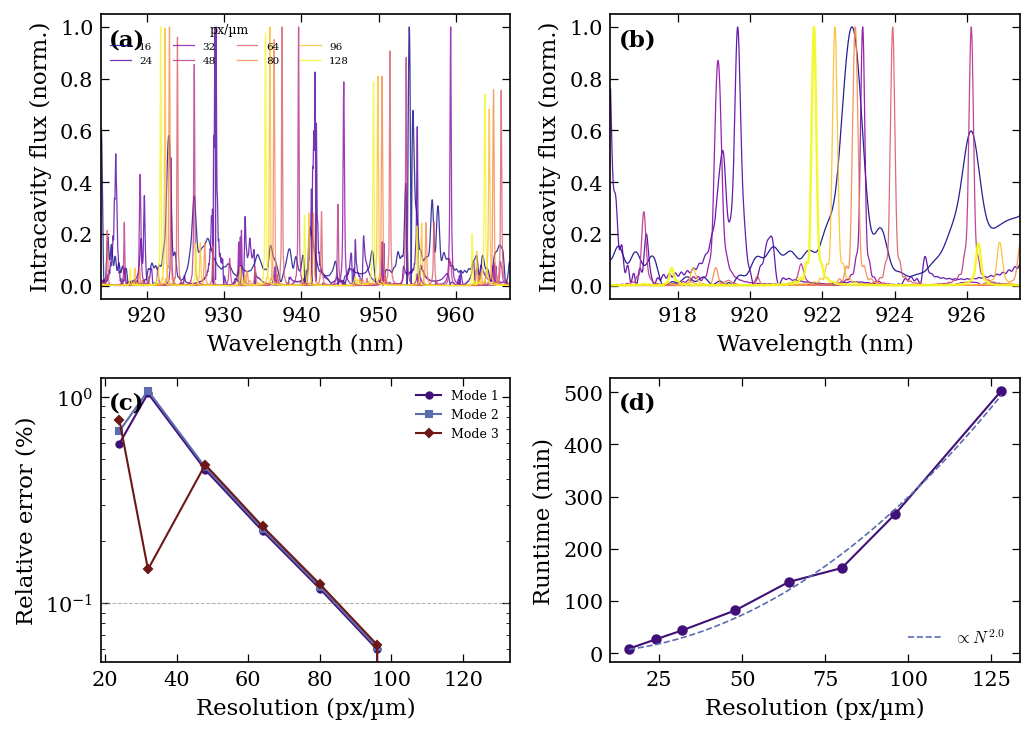

In [113]:
# ============================================================
# Combined 2×2 figure for thesis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(DBL_WIDTH, 5.0))
(ax_spec, ax_zoom, ax_conv, ax_rt) = axes.flat

# --- (a) Full spectra overlay (normalized) ---
for res in resolutions:
    f = freqs_dict[res]
    mask = (f >= FREQ_MIN) & (f <= FREQ_MAX)
    wl = thz_to_nm(f[mask])
    spec = spectra_disk[res][mask].copy()
    smax = spec.max()
    if smax > 0:
        spec /= smax
    color = res_color(res, resolutions)
    ax_spec.plot(wl, spec, color=color, linewidth=0.6, alpha=0.8,
                 label=f"{res}")
ax_spec.set_xlabel("Wavelength (nm)")
ax_spec.set_ylabel("Intracavity flux (norm.)")
ax_spec.set_xlim(WL_MIN, WL_MAX)
ax_spec.legend(title="px/µm", fontsize=5, title_fontsize=6,
               ncol=4, loc="upper left")

# --- (b) Zoom on one peak (normalized) ---
for res in resolutions:
    f = freqs_dict[res]
    mask = (f >= f_peak - ZOOM_HALF) & (f <= f_peak + ZOOM_HALF)
    wl = thz_to_nm(f[mask])
    spec = spectra_disk[res][mask].copy()
    smax = spec.max()
    if smax > 0:
        spec /= smax
    color = res_color(res, resolutions)
    lw = 1.2 if res == ref_res else 0.6
    ax_zoom.plot(wl, spec, color=color, linewidth=lw, alpha=0.9)
ax_zoom.set_xlabel("Wavelength (nm)")
ax_zoom.set_ylabel("Intracavity flux (norm.)")
ax_zoom.set_xlim(wl_zoom_min, wl_zoom_max)

# --- (c) Relative error convergence ---
for k in tracked:
    valid = ~np.isnan(tracked[k])
    rel_err = np.abs(tracked[k][valid] - ref_vals[k]) / ref_vals[k] * 100
    ax_conv.plot(tracked_res[valid], rel_err,
                 f"{markers[k]}-", color=colors_peak[k],
                 markersize=3, linewidth=1.0,
                 label=f"Mode {k+1}")
ax_conv.set_xlabel("Resolution (px/µm)")
ax_conv.set_ylabel("Relative error (%)")
ax_conv.set_yscale("log")
ax_conv.legend(fontsize=6)
ax_conv.axhline(0.1, color="gray", ls="--", lw=0.5, alpha=0.6)

# --- (d) Runtime scaling ---
ax_rt.plot(resolutions, runtimes / 60, "o-", color="#400F77",
           markersize=4, linewidth=1.0)
ax_rt.plot(res_fine, power_law(res_fine, *popt) / 60, "--",
           color="#5B6DAE", linewidth=0.8,
           label=f"$\\propto N^{{{b_fit:.1f}}}$")
ax_rt.set_xlabel("Resolution (px/µm)")
ax_rt.set_ylabel("Runtime (min)")
ax_rt.legend(fontsize=8)

# Panel labels
for ax, label in zip(axes.flat, ["(a)", "(b)", "(c)", "(d)"]):
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"convergence_combined.{ext}"))
    print(f"Saved: {fig_dir}/convergence_combined.pdf")
plt.show()